# Face verification system by Principal Component Analysis (PCA)

## The face database

For this homework we will work on face verification (Given a face, say whether it is person A or
not). Face verification is quite related to face recognition (Given a face, say who it is). Face
verification is a binary classification task, while face recognition is a multi-class problem.
Download the file “facedata.mat”. You can load the data by

In [140]:
import scipy.io
import numpy as np

### Load & Play data

In [141]:
data = scipy.io.loadmat('facedata.mat')
# face data is a 2-dimensional array with size 40x10
print(data['facedata'].shape) # 40 person, 10 pose

(40, 10)


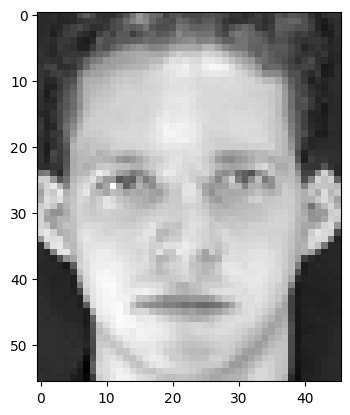

In [142]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.imshow(data['facedata'][0,0],cmap="gray")
plt.show()

In [143]:
from skimage import img_as_float
xf = {}
xf[0,0] = img_as_float(data['facedata'][0,0])
print(f"image shape:{xf[0,0].shape}")

image shape:(56, 46)


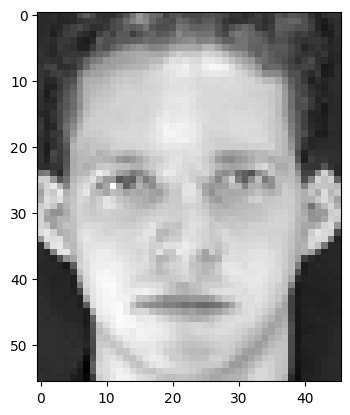

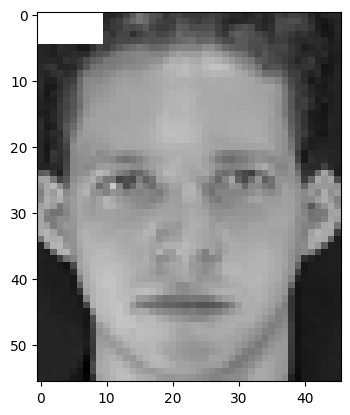

In [144]:
plt.imshow(xf[0,0],cmap="gray")
plt.show()
x_temp = xf[0,0].copy()
x_temp[0:5,0:10] = 1
# In float format, 1 is white
plt.imshow(x_temp,cmap="gray")
plt.show()

### **Part 1**

What is the Euclidean distance between xf[0,0] and xf[0,1]? What is the Euclidean
distance between xf[0,0] and xf[1,0]? Does the numbers make sense? Do you think these numbers
will be useful for face verification? Why?

In [145]:
xf1 = {}
xf1[0,0] = img_as_float(data['facedata'][0,0])
xf1[1,0] = img_as_float(data['facedata'][1,0])

img0 = xf1[0,0] #.reshape(-1)
img1 = xf1[1,0] #.reshape(-1)
# print(img0.shape) # 2576

similarity = np.sqrt(np.sum((img0 - img1)**2))
print(f"Similarity (Euclidean distance): {similarity}")

Similarity (Euclidean distance): 8.173295099737281


#### **Answer**
- Distance between $xf[0,0]$ and $xf[0,1]$ is **`8.173295099737281`**

- **`No`** this number only show the distance between the picture, but in face verification should be consider the face structure, which not the point to point distance. It should consider the main feature such as the `eye`, `mouth`, `ear` or etc. On the same way, less distance do not mean that the image is the same as the face.


### **Part 2**

As we continue our exercise, we will refine our feature vectors so that the Euclidean distance
between two images can be used in a face verification system.

We define the similarity matrix, $A$, as a matrix whose elements $A_{i,j}$ is the Euclidean distance
between data sample $i$ from list $T$ and data sample $j$ from list $D$, where list $T$,$D$ are lists of data
samples.

**Write a function that takes in a set of feature vectors $T$ and a set of feature vectors $D$, and then output the similarity matrix $A$**. Show the matrix as an image. Use the feature vectors from the first 3 images from all 40 people for list $T$ (in order x[0, 0], x[0, 1], x[0, 2], x[1, 0], x[1, 1],
...x[39, 2]). Use the feature vectors from the remaining 7 images from all 40 people for list $D$ (in
order x[0, 3], x[0, 4], x[0, 5], x[1, 6], x[0, 7], x[0, 8], x[0, 9], x[1, 3], x[1, 4]...x[39, 9]). We will treat
$T$ as our training images and $D$ as our testing images.

In [146]:
xf2_full = {}
for people in range(40):
    for pose in range(10):
        xf2_full[people, pose] = img_as_float(data['facedata'][people, pose])

In [147]:
num_people = 40
num_train_pose = 3
num_test_pose = 7

xf2_train = {}
xf2_test = {}
for people in range(num_people):
    for pose in range(num_train_pose):
        xf2_train[people, pose] = img_as_float(data['facedata'][people, pose])

for people in range(num_people):
    for pose in range(num_test_pose):
        xf2_test[people, pose] = img_as_float(data['facedata'][people, pose])

#### **Answer**

In [148]:
def similarity_matrix(T,D):
    """ Calculating the simlarity of matrix T and D with euclidean distance """
    # A = np.sqrt(np.sum((T - D)**2))
    A = np.linalg.norm(T - D)
    return A

- example run of our code

In [149]:
A = similarity_matrix(T=xf2_full[0,0] , D=xf2_full[1,0])
print(f"Similarity: {A}")

Similarity: 8.173295099737281


In our simple face verification system, given a test image, we want to test if that image comes from person A or not. We will compare the test image against the three training images from person $A$ we have. If the minimum distance (between the three training images) is below a threshold, $t$, we say that the test image is person $A$.

In [150]:
target_A = 0
threshold = 10

for i in range(3):
    dist = similarity_matrix(T=xf2_train[target_A,i] , D=xf2_test[target_A,0])
    if dist < threshold:
        print("This is Person A!")
        break
    else:
        print("This is not Person A!")

This is Person A!


### **Part 3**

**Write a function that takes in the similarity matrix created from the previous part**, and a threshold $t$ as inputs. The outputs of the function are the true positive rate and the false alarm rate of the face verification task (280 Test images, tested on 40 people). What is the true
positive rate and the false alarm rate for $t = 10$? (5 points)

In [151]:
sim = np.zeros((280,num_people,num_train_pose)) # [test figure, train person, train pose]

for num_fig,test_dict in enumerate(xf2_test):
    for check_people in range(num_people):
        for check_pose in range(num_train_pose):
            sim[num_fig, check_people, check_pose] = similarity_matrix(xf2_test[test_dict] , xf2_train[check_people,check_pose])

In [152]:
def face_verification(similarity, t):
    '''
    similarity: the similarity score between the test image and the training image
    t: the threshold for verification
    '''
    TP = 0 ; TN = 0
    FP = 0 ; FN = 0
    
    shape_image , person , pose = similarity.shape
    for image in range(shape_image):
        for check_person in range(person):
            for check_pose in range(pose):
                if similarity[image, check_person, check_pose] < t:
                    if check_person == image%num_people:
                        TP += 1
                    else:
                        FP += 1
                else:
                    if check_person == image%num_people:
                        FN += 1
                    else:
                        TN += 1
    
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FAR = FP / (FP + TN) if (FP + TN) > 0 else 0
    result = {
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TPR": TPR,
        "FAR": FAR
    }
    return result

In [159]:
result = face_verification(similarity=sim, t=10)
print(f"True Positive Rate: {result['TPR']}")
print(f"False Alarm Rate: {result['FAR']}")
print(f"TP: {result['TP']}, TN: {result['TN']}, FP: {result['FP']}, FN: {result['FN']}")

True Positive Rate: 0.43214285714285716
False Alarm Rate: 0.3687728937728938
TP: 363, TN: 20679, FP: 12081, FN: 477


### **Part 4**
Plot the RoC curve (curve between the true positive rate (TP) as y-axis and the false alarm rate (false positive rate or FP) as x-axis) for this simple verification system when threshold changes. What should be the minimum threshold to generate the RoC curve? What should be the maximum threshold? Your RoC should be generated from at least 1000 threshold levels equally spaced between the minimum and the maximum. (You should write a function for this).

In [165]:
num_thresholds = 2000
thresholds = np.arange(0, num_thresholds, 1)
tpr = np.zeros(num_thresholds)
far = np.zeros(num_thresholds)

for i in thresholds:
    result = face_verification(similarity=sim, t=i)
    tpr[i] = result['TPR']
    far[i] = result['FAR']

    # print(f"Threshold: {i}, TPR: {result['TPR']}, FAR: {result['FAR']}")

In [166]:
def roc_curve(true_positive_rate, false_alarm_rate):
    plt.figure(figsize=(8, 6))
    plt.plot(false_alarm_rate, true_positive_rate, marker='o')
    plt.title('ROC Curve')
    plt.xlabel('False Alarm Rate (FAR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.grid()
    plt.show()

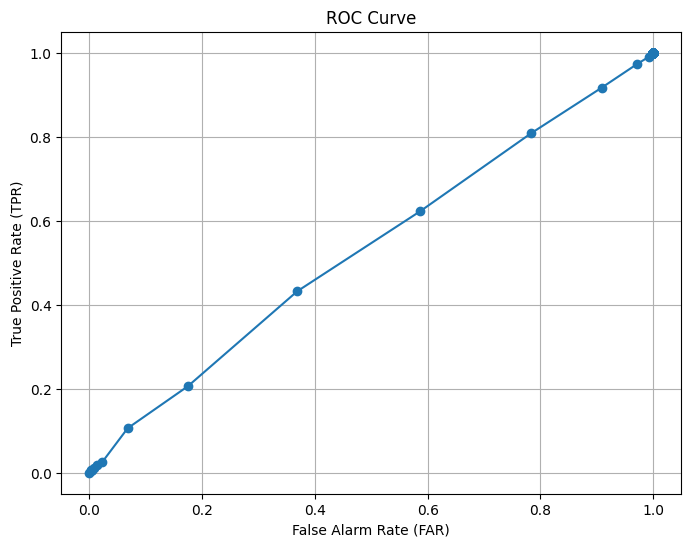

In [167]:
roc_curve(true_positive_rate=tpr, false_alarm_rate=far)